In [52]:
# import libraries

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from google.cloud import bigquery

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

In [53]:
# Load Dataset from BigQuery

from google.cloud import bigquery
client = bigquery.Client(project="gridzero-489711")

query = """
SELECT *
FROM `gridzero-489711.merged_set.full_feature_engineered_data_test`
ORDER BY datetime
"""

df = client.query(query).to_dataframe()
print(df.shape)
df.head()

(148991, 31)


,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,carbon_intensity_gco2_kwh,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520
0,2017-09-12 00:00:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,142.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
1,2017-09-12 00:30:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,140.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
2,2017-09-12 01:00:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,139.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
3,2017-09-12 01:30:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,137.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
4,2017-09-12 02:00:00+00:00,10.9,29.6,25.2,7.0,0.0,0.0,0.0,1002.4,0.0,...,132.0,0.500000,0.866025,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN


In [54]:
# inspect columns
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(30))

Columns:
['datetime', 'temperature_2m_c', 'wind_speed_100m_ms', 'wind_gusts_10m_ms', 'cloud_cover_pct', 'shortwave_radiation_wm2', 'direct_radiation_wm2', 'diffuse_radiation_wm2', 'pressure_msl_hpa', 'precipitation_mm', 'biomass', 'fossil_gas', 'fossil_hard_coal', 'hydro_pumped_storage', 'hydro_run_of_river_and_poundage', 'nuclear', 'other', 'solar', 'wind_offshore', 'wind_onshore', 'totaloutput_mw', 'carbon_intensity_gco2_kwh', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'carbon_lag_48', 'carbon_lag_336', 'carbon_lag_17520']

Missing values:


carbon_lag_17520                   17699
carbon_lag_336                       515
carbon_lag_48                        227
wind_gusts_10m_ms                      0
datetime                               0
temperature_2m_c                       0
wind_speed_100m_ms                     0
diffuse_radiation_wm2                  0
pressure_msl_hpa                       0
precipitation_mm                       0
biomass                                0
fossil_gas                             0
cloud_cover_pct                        0
shortwave_radiation_wm2                0
direct_radiation_wm2                   0
hydro_run_of_river_and_poundage        0
hydro_pumped_storage                   0
fossil_hard_coal                       0
nuclear                                0
wind_onshore                           0
other                                  0
solar                                  0
wind_offshore                          0
hour_sin                               0
carbon_intensity

## Convert datetime and sort chronologically

Since this is a forecasting problem, we sort the dataset by time.

In [55]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print("Date range:")
print(df["datetime"].min(), "to", df["datetime"].max())

Date range:
2017-09-12 00:00:00+00:00 to 2026-03-12 23:00:00+00:00


In [58]:
## Handle missing lag features
lag_features = [
    "carbon_lag_48",
    "carbon_lag_336",
    "carbon_lag_17520"
]

print("Rows before dropping lag NaNs:", len(df))

df = df.dropna(subset=lag_features).reset_index(drop=True)

print("Rows after dropping lag NaNs:", len(df))
print("\nRemaining missing values in lag columns:")
print(df[lag_features].isnull().sum())


Rows before dropping lag NaNs: 130934
Rows after dropping lag NaNs: 130934

Remaining missing values in lag columns:
carbon_lag_48       0
carbon_lag_336      0
carbon_lag_17520    0
dtype: int64


## Create rolling features

These rolling features help the model capture short-term and weekly carbon intensity trends.

We use:
- 24-hour rolling mean
- 168-hour rolling mean (7 days)

In [57]:
df["carbon_roll_24h"] = df["carbon_intensity_gco2_kwh"].shift(1).rolling(24).mean()
df["carbon_roll_168h"] = df["carbon_intensity_gco2_kwh"].shift(1).rolling(168).mean()

print(df[["carbon_roll_24h", "carbon_roll_168h"]].head(10))

   carbon_roll_24h  carbon_roll_168h
0              NaN               NaN
1              NaN               NaN
2              NaN               NaN
3              NaN               NaN
4              NaN               NaN
5              NaN               NaN
6              NaN               NaN
7              NaN               NaN
8              NaN               NaN
9              NaN               NaN


## Drop rows created as missing by rolling windows

Rolling calculations create missing values at the start of the remaining dataset.
We remove them before training.

In [23]:
print("Rows before dropping rolling NaNs:", len(df))

df = df.dropna(subset=["carbon_roll_24h", "carbon_roll_168h"]).reset_index(drop=True)

print("Rows after dropping rolling NaNs:", len(df))

Rows before dropping rolling NaNs: 130934
Rows after dropping rolling NaNs: 130767


## Target and Features

In [24]:
target = "carbon_intensity_gco2_kwh"

features = [
    "temperature_2m_c",
    "wind_speed_100m_ms",
    "wind_gusts_10m_ms",
    "cloud_cover_pct",
    "shortwave_radiation_wm2",
    "direct_radiation_wm2",
    "diffuse_radiation_wm2",
    "pressure_msl_hpa",
    "precipitation_mm",
    "biomass",
    "fossil_gas",
    "fossil_hard_coal",
    "hydro_pumped_storage",
    "hydro_run_of_river_and_poundage",
    "nuclear",
    "other",
    "solar",
    "wind_offshore",
    "wind_onshore",
    "totaloutput_mw",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
    "carbon_lag_48",
    "carbon_lag_336",
    "carbon_lag_17520",
    "carbon_roll_24h",
    "carbon_roll_168h"
]

X = df[features].copy()
y = df[target].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(features))

Feature matrix shape: (130767, 31)
Target shape: (130767,)
Number of features: 31


In [26]:
# Sanity check
print("Any missing values left in features?", X.isnull().sum().sum())
print("Any missing values left in target?", y.isnull().sum())

Any missing values left in features? 0
Any missing values left in target? 0


## Time-based train/test split

We split the data chronologically:
- first 80% for training
- last 20% for testing

This avoids leakage from future data.

In [27]:
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain period:")
print(train_df["datetime"].min(), "to", train_df["datetime"].max())

print("\nTest period:")
print(test_df["datetime"].min(), "to", test_df["datetime"].max())

Train shape: (104613, 31) (104613,)
Test shape: (26154, 31) (26154,)

Train period:
2018-09-15 11:30:00+00:00 to 2024-09-11 13:00:00+00:00

Test period:
2024-09-11 13:30:00+00:00 to 2026-03-12 23:00:00+00:00


## Train HistGradientBoostingRegressor

In [28]:
model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=400,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


## Generate predictions on the test set

In [29]:
predictions = model.predict(X_test)

predictions[:10]

array([ 45.64508026,  43.34739731,  49.08497525,  62.08312256,
        76.16359273,  82.68560299, 113.68929244, 135.8225299 ,
       140.95789869, 128.3756967 ])

## Evaluate model performance

We compute:
- MAE
- RMSE
- R²

In [30]:
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

MAE : 9.6842
RMSE: 12.5512
R²  : 0.9544


## Actual vs Predicted Carbon Intensity
This plot compares the real carbon intensity values with the model predictions over time.

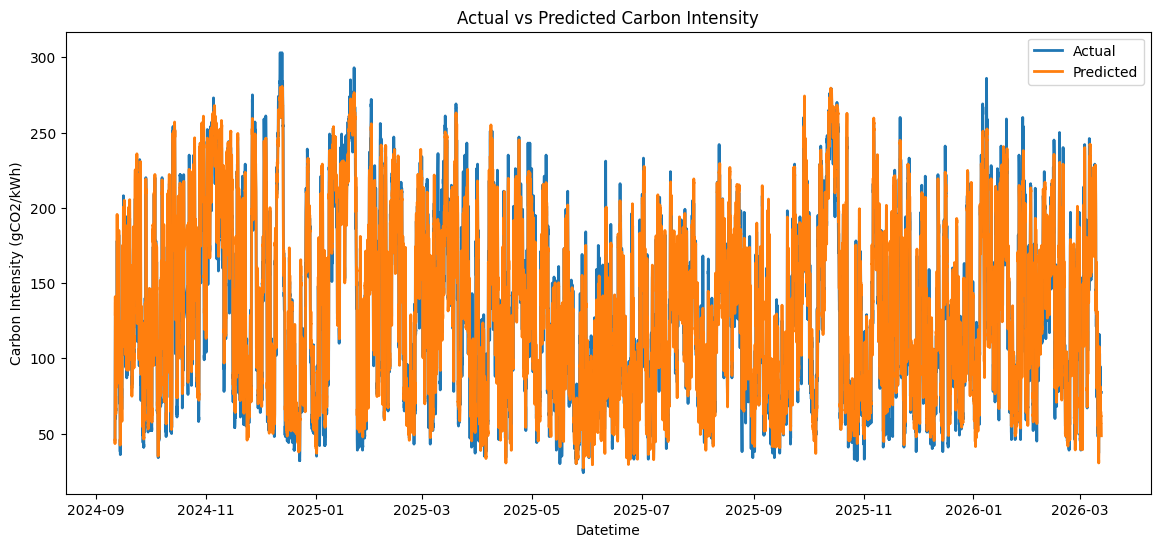

In [44]:
plt.figure(figsize=(14,6))

plt.plot(test_df["datetime"], y_test, label="Actual", linewidth=2)
plt.plot(test_df["datetime"], predictions, label="Predicted", linewidth=2)

plt.title("Actual vs Predicted Carbon Intensity")
plt.xlabel("Datetime")
plt.ylabel("Carbon Intensity (gCO2/kWh)")
plt.legend()

plt.show()

## Prediction Error Distribution
This histogram shows the distribution of prediction errors.

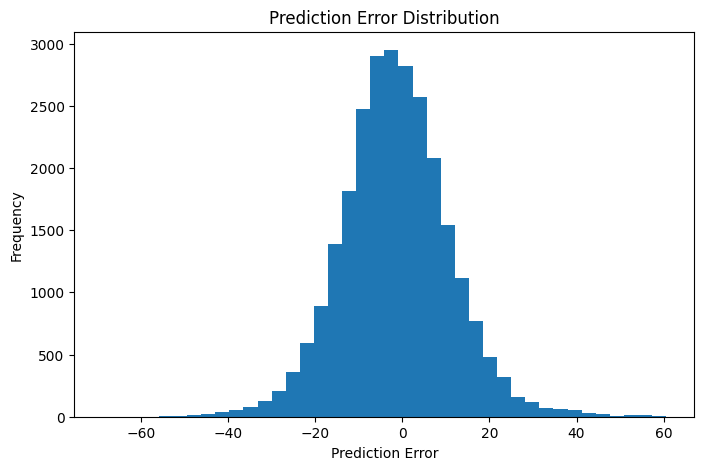

In [36]:
errors = y_test - predictions

plt.figure(figsize=(8,5))

plt.hist(errors, bins=40)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

## Actual vs Predicted Scatter Plot
A perfect model would produce a straight diagonal line.

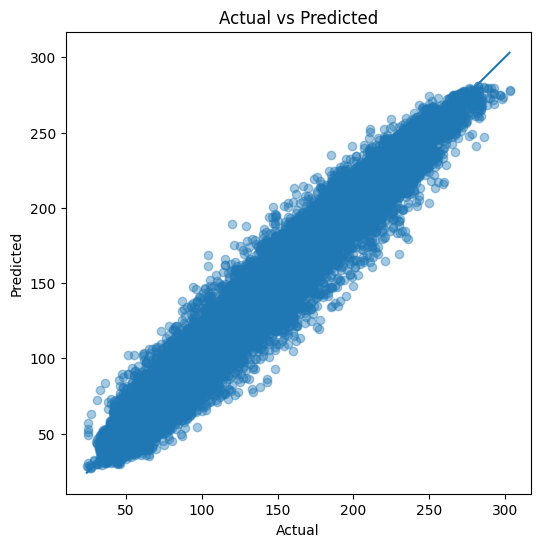

In [45]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions, alpha=0.4)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.show()

## Feature Importance
This plot shows which features most influence the model predictions.

In [46]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

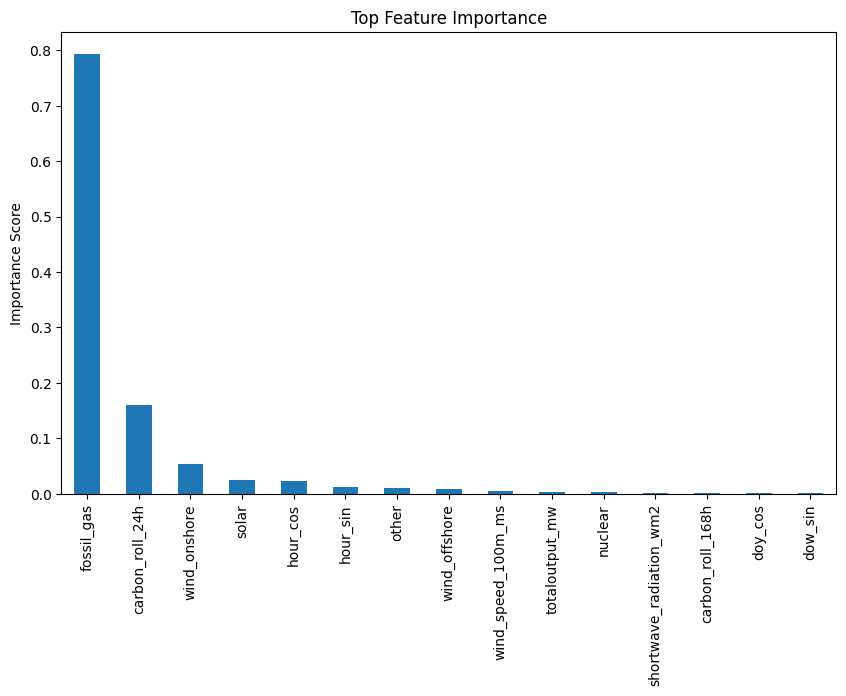

In [47]:
plt.figure(figsize=(10,6))

importance.head(15).plot(kind="bar")

plt.title("Top Feature Importance")
plt.ylabel("Importance Score")

plt.show()

## Create a results dataframe

In [48]:
results = pd.DataFrame({
    "datetime": test_df["datetime"].values,
    "actual": y_test.values,
    "predicted": predictions
})

results.head()

,datetime,actual,predicted
0,2024-09-11 13:30:00,46.0,45.645080
1,2024-09-11 14:00:00,53.0,43.347397
2,2024-09-11 14:30:00,60.0,49.084975
3,2024-09-11 15:00:00,71.0,62.083123
4,2024-09-11 15:30:00,85.0,76.163593


In [49]:
## Save model to disk
os.makedirs("../models", exist_ok=True)

model_path = "../models/hgb_model.joblib"
joblib.dump(model, model_path)

print("Model saved to:", model_path)

Model saved to: ../models/hgb_model.joblib


In [50]:
# save predictions to CSV for later analysis
predictions_path = "../models/hgb_predictions.csv"
results.to_csv(predictions_path, index=False)

print("Predictions saved to:", predictions_path)

Predictions saved to: ../models/hgb_predictions.csv


In [51]:
## Save evaluation summary
summary = pd.DataFrame({
    "model": ["HistGradientBoostingRegressor"],
    "target": [target],
    "n_features": [len(features)],
    "train_rows": [len(X_train)],
    "test_rows": [len(X_test)],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

summary

,model,target,n_features,train_rows,test_rows,MAE,RMSE,R2
0,HistGradientBoostingRegressor,carbon_intensity_gco2_kwh,31,104613,26154,9.684206,12.551169,0.954415
